In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
from matplotlib.lines import Line2D

In [20]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"


In [2]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))
        
rho_rec_or = np.log10(rho_rec_or)
ef_kin_or  = np.log10(ef_kin_or)

In [3]:
import re

def extract_last_sync_counts(filename="info.txt"):
    try:
        with open(filename, 'rb') as f:
            # Seek to the end and find the last line
            f.seek(-1024, 2) # Go to the last 1KB of the file
            last_line = f.readlines()[-1].decode('utf-8')
        
        # Regex to find the numbers following the specific labels
        grv_match = re.search(r"Nsync-grv:\s+(\d+)", last_line)
        hyd_match = re.search(r"Nsync-hyd:\s+(\d+)", last_line)
        
        return int(grv_match.group(1))

    except FileNotFoundError:
        return "File not found."
    except Exception as e:
        return f"An error occurred: {e}"
    
def extract_cpu_number(filename="cpu.txt"):
    try:
        with open(filename, 'r') as f:
            first = f.readline()
        
        # Regex to find the numbers following the specific labels
        cpu_match = re.search(r"CPUs:\s+(\d+)", first)
        
        return int(cpu_match.group(1))
            
    except FileNotFoundError:
        return "File not found."
    except Exception as e:
        return f"An error occurred: {e}"

In [6]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

part_n = np.zeros(len(name_list)+1)
cpu_n = np.zeros(len(name_list)+1)
step = {}
total_cpu = np.zeros(len(name_list)+1)

for i in range(len(name_list)):
    print("Processing: {}".format(name_list[i]))
    basedir = "/cosmos_storage/simulations/TNG_Family/MN5_resims/{}/hydro_output/".format(name_list[i])

    part_n[i] = extract_last_sync_counts(basedir+"info.txt")
    cpu_n[i] = extract_cpu_number(basedir+"cpu.txt")
    # step[name_list[i]] = np.loadtxt(basedir+"step.csv")
    total_cpu[i] = np.loadtxt(basedir+"total_cpu.csv")[-1]

part_n[-1] = 360907131
cpu_n[-1] = 768
total_cpu[-1] = 1100697.39

Processing: LH_0
Processing: LH_1
Processing: LH_2
Processing: LH_3
Processing: LH_4
Processing: LH_5
Processing: LH_6
Processing: LH_7
Processing: LH_8
Processing: LH_9
Processing: LH_10
Processing: LH_11
Processing: LH_12
Processing: LH_13
Processing: LH_14
Processing: LH_15
Processing: LH_16
Processing: LH_17
Processing: LH_18
Processing: LH_19
Processing: LH_20
Processing: LH_21
Processing: LH_22
Processing: LH_23
Processing: LH_24
Processing: LH_25
Processing: LH_26
Processing: LH_27
Processing: LH_28
Processing: LH_29
Processing: fiducial


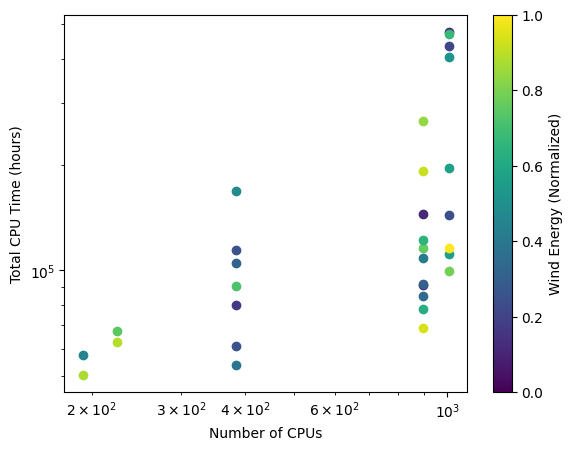

In [7]:
cmap = matplotlib.cm.get_cmap('viridis')

fig, ax = plt.subplots(dpi=100, figsize=(6.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel("Number of CPUs")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    ax.plot(cpu_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o', c=cmap(wind_en_or[i]/np.max(wind_en_or)))

plt.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap), label='Wind Energy (Normalized)')

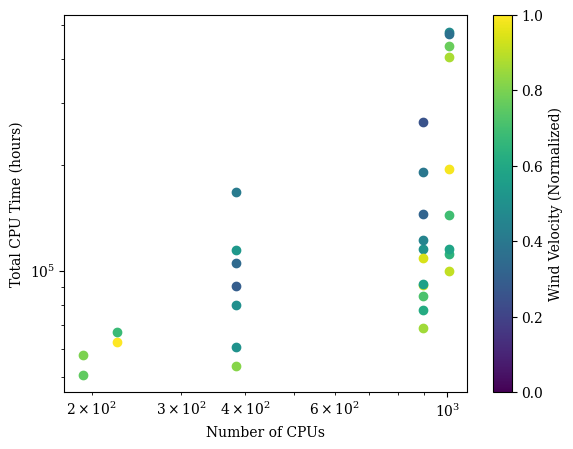

In [41]:
cmap = matplotlib.cm.get_cmap('viridis')

fig, ax = plt.subplots(dpi=100, figsize=(6.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel("Number of CPUs")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    ax.plot(cpu_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o', c=cmap(wind_vel_or[i]/np.max(wind_vel_or)))

plt.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap), label='Wind Velocity (Normalized)')

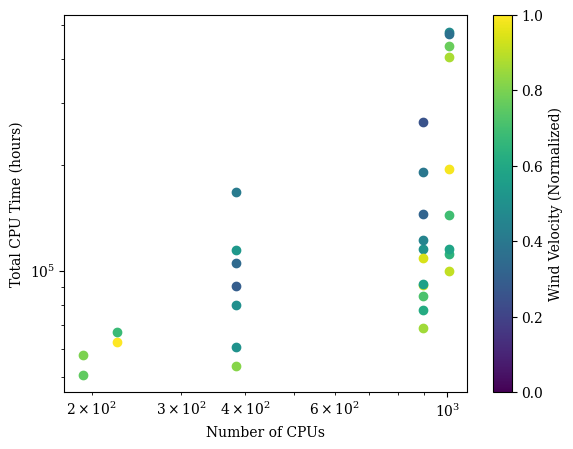

In [60]:
cmap = matplotlib.cm.get_cmap('viridis')

fig, ax = plt.subplots(dpi=100, figsize=(6.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel("Number of CPUs")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    ax.plot(cpu_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o', c=cmap(wind_vel_or[i]/np.max(wind_vel_or)))

plt.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap), label='Wind Velocity (Normalized)')

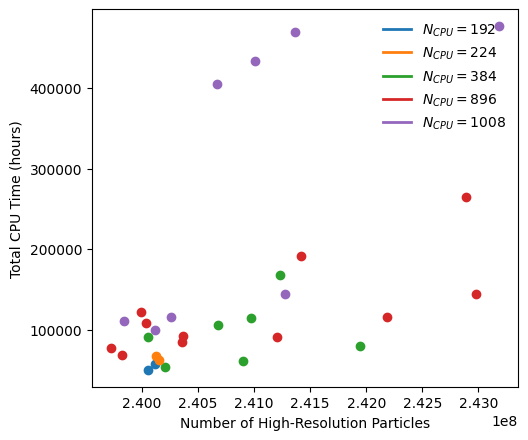

In [8]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.set_xscale('linear')
ax.set_yscale('linear')

ax.set_xlabel("Number of High-Resolution Particles")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    if i==26:
        continue
    if cpu_n[i] == 192:
        ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',\
            c='C0', label="192 CPUs")
    if cpu_n[i] == 224:
        ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',\
            c='C1', label="224 CPUs")
    if cpu_n[i] == 384:
        ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',\
            c='C2', label="384 CPUs")
    if cpu_n[i] == 896:
        ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',\
            c='C3', label="896 CPUs")
    if cpu_n[i] == 1008:
        ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',\
            c='C4', label="1008 CPUs") 

legend_elements = [
    Line2D([0], [0], color='C0', lw=2, label='$N_{CPU}=192$'),
    Line2D([0], [0], color='C1', lw=2, label='$N_{CPU}=224$'),
    Line2D([0], [0], color='C2', lw=2, label='$N_{CPU}=384$'),
    Line2D([0], [0], color='C3', lw=2, label='$N_{CPU}=896$'),
    Line2D([0], [0], color='C4', lw=2, label='$N_{CPU}=1008$')
]

ax.legend(handles=legend_elements, loc='upper right', frameon=False)


In [ ]:
# wind_en_or      = []
# wind_vel_or     = []
# rho_rec_or      = []
# sf_ts_or        = []
# ef_kin_or       = []
# ef_high_or      = []
# f_re_or         = []

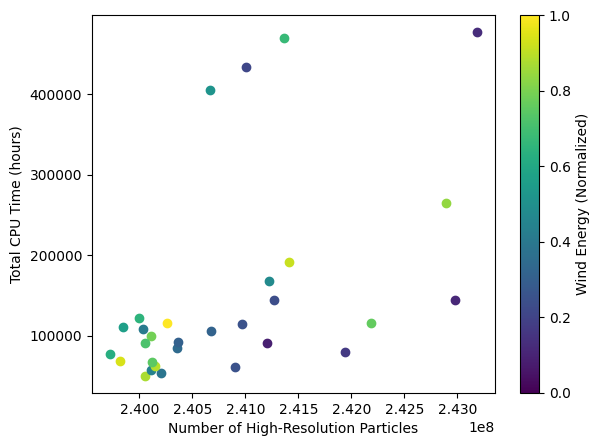

In [9]:
fig, ax = plt.subplots(dpi=100, figsize=(6.5,5))

ax.set_xscale('linear')
ax.set_yscale('linear')

ax.set_xlabel("Number of High-Resolution Particles")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    if i==26:
        continue
    ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',c=cmap(wind_en_or[i]/np.max(wind_en_or)))

plt.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap), label='Wind Energy (Normalized)')

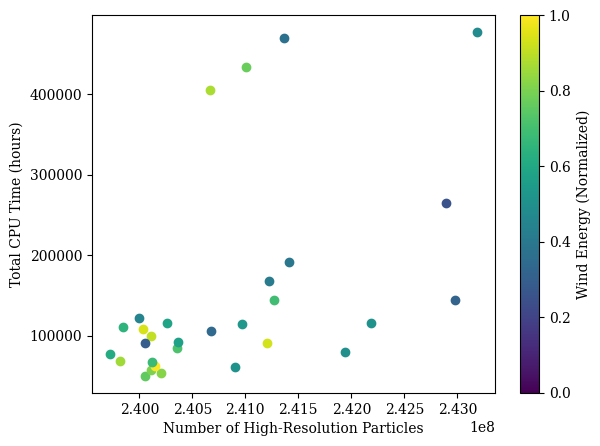

In [39]:
fig, ax = plt.subplots(dpi=100, figsize=(6.5,5))

ax.set_xscale('linear')
ax.set_yscale('linear')

ax.set_xlabel("Number of High-Resolution Particles")
ax.set_ylabel("Total CPU Time (hours)")

for i in range(len(name_list)):
    if i==26:
        continue
    ax.plot(part_n[i], total_cpu[i] * cpu_n[i] / 3600, ls='', marker='o',c=cmap(wind_vel_or[i]/np.max(wind_vel_or)))

plt.colorbar(matplotlib.cm.ScalarMappable(cmap=cmap), label='Wind Energy (Normalized)')

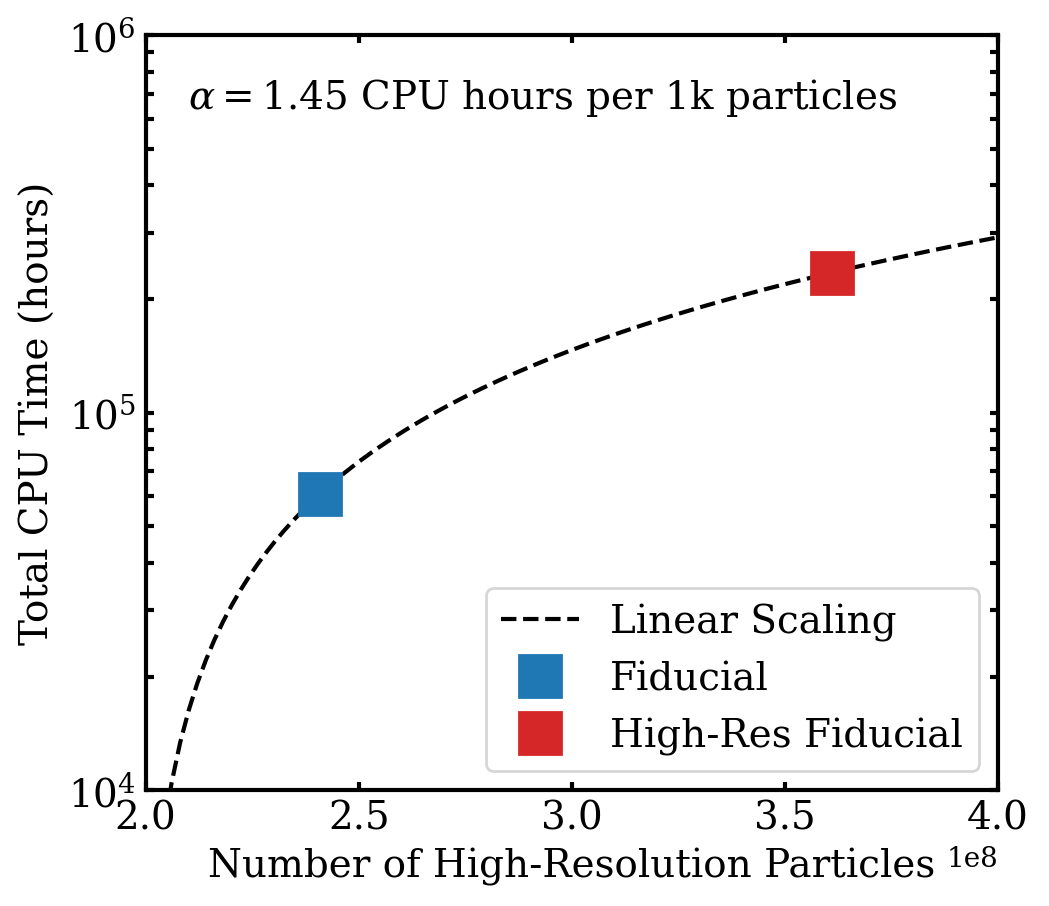

In [38]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('linear')
ax.set_yscale('log')

ax.set_xlabel("Number of High-Resolution Particles", fontsize=14)
ax.set_ylabel("Total CPU Time (hours)", fontsize=14)

ax.set_xlim(2*1e8,4*1e8)
ax.set_ylim(1e4,1e6)

alpha = 1000 * (total_cpu[31]*cpu_n[31]/3600-total_cpu[30]*cpu_n[30]/3600) / (part_n[31] - part_n[30])
ax.text(2.1e8,  # x-coordinate
    6e5,  # y-coordinate
    "$\\alpha = {:.2f}$ CPU hours per 1k particles".format(alpha),
    fontsize=14, color='k', ha='left', va='bottom'
)

x = np.linspace(2e8, 4e8, 100)
ax.plot(x, total_cpu[30]*cpu_n[30]/3600 + alpha * (x - part_n[30])/1000, ls='--', color='k', label="Linear Scaling")

ax.plot(part_n[30], total_cpu[30] * cpu_n[30] / 3600, ls='', marker='s', ms=15, color="C0", label="Fiducial")
ax.plot(part_n[31], total_cpu[31] * cpu_n[31] / 3600, ls='', marker='s', ms=15, color="C3", label="High-Res Fiducial")

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.5, length=3, labelsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Adjust thickness as desired

ax.legend(fontsize=14, loc='lower right')

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/performance/figures/cpu_scaling_npart.pdf", bbox_inches='tight')

Text(0.5, 1.0, 'Top 10 Contributors to LH_9')

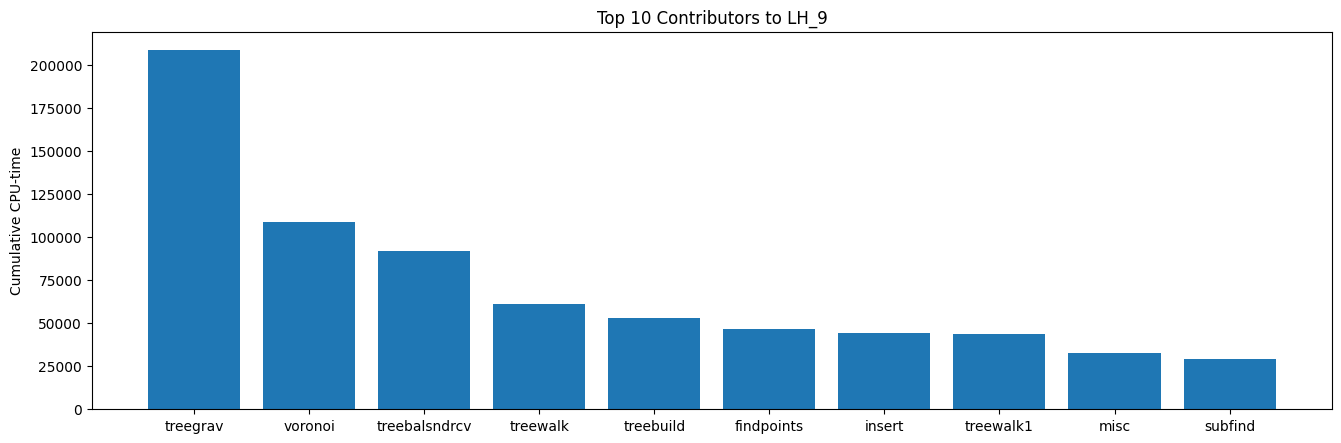

In [11]:
import re
import matplotlib.pyplot as plt

# Paste your log text here
log_text = """
total                   901.07  100.0%   0.00  504106.78  100.0%
  treegrav               39.71    4.4%   0.10  209102.75        41.5%
    treebuild             1.97    0.2%   0.24   53317.89             10.6%
      insert              1.42    0.2%   1.46   44241.74                   8.8%
      toplevel            0.14    0.0%   0.17    5033.20                   1.0%
    treewalk             22.22    2.5%   0.00   61434.26             12.2%
      treewalk1          15.69    1.7%  20.42   43680.27                   8.7%
      treewalk2           6.53    0.7%  10.91   17753.99                   3.5%
    treebalsndrcv        15.14    1.7%  20.18   91943.19             18.2%
  pm_grav                11.82    1.3%  11.95   15715.94         3.1%
  voronoi                30.41    3.4%   0.41  108763.40        21.6%
    insert                5.87    0.7%   6.64    9858.18              2.0%
    findpoints           20.16    2.2%  20.84   46829.76              9.3%
    cellcheck             0.98    0.1%   1.34    1708.86              0.3%
    geometry              2.26    0.3%   2.33   21738.25              4.3%
    exchange              0.46    0.1%   0.52    5117.30              1.0%
  hydro                   2.61    0.3%   0.00   23787.64         4.7%
    gradients             0.00    0.0%   0.00    4798.62              1.0%
    fluxes                2.26    0.3%   2.42   11729.10              2.3%
    fluxcomm              0.29    0.0%   0.53    6928.23              1.4%
  GFM                     1.09    0.1%   0.00   18102.68         3.6%
    enrich                0.49    0.1%   0.52    9958.05              2.0%
    agnrad                0.54    0.1%   1.09    7943.61              1.6%
  domain                  6.69    0.7%   0.20    8803.45         1.7%
    exchange              4.49    0.5%   5.08    6762.40              1.3%
  treetimesteps           0.00    0.0%   0.00    8649.39         1.7%
  sfrcool                 3.62    0.4%   4.05    8903.27         1.8%
  fof                    11.86    1.3%  11.94    5524.89         1.1%
  subfind               191.28   21.2% 191.38   28996.46         5.8%
  mesh_derefine           0.00    0.0%   0.00    6262.68         1.2%
  restart               390.69   43.4% 390.71   10444.16         2.1%
  misc                   92.88   10.3%  93.36   32686.27         6.5%
"""

# Regex to extract task and cumulative time (4th column)
pattern = re.compile(r'^\s*([a-zA-Z0-9_]+)\s+[\d\.]+\s+[\d\.]+%\s+[\d\.]+\s+([\d\.]+)', re.MULTILINE)
matches = pattern.findall(log_text)

# Build a list of (task, cumulative_time)
tasks = [(name, float(cum)) for name, cum in matches if name != 'total']

# Sort by cumulative_time descending
tasks.sort(key=lambda x: x[1], reverse=True)

# Take top 10
top10 = tasks[:10]
labels, values = zip(*top10)

fig, ax = plt.subplots(dpi=100, figsize=(16,5))

# Plot
ax.bar(labels, values, color='C0')
ax.set_ylabel('Cumulative CPU-time')
ax.set_title('Top 10 Contributors to LH_9')


Text(0.5, 1.0, 'Top 10 Contributors to LH_10')

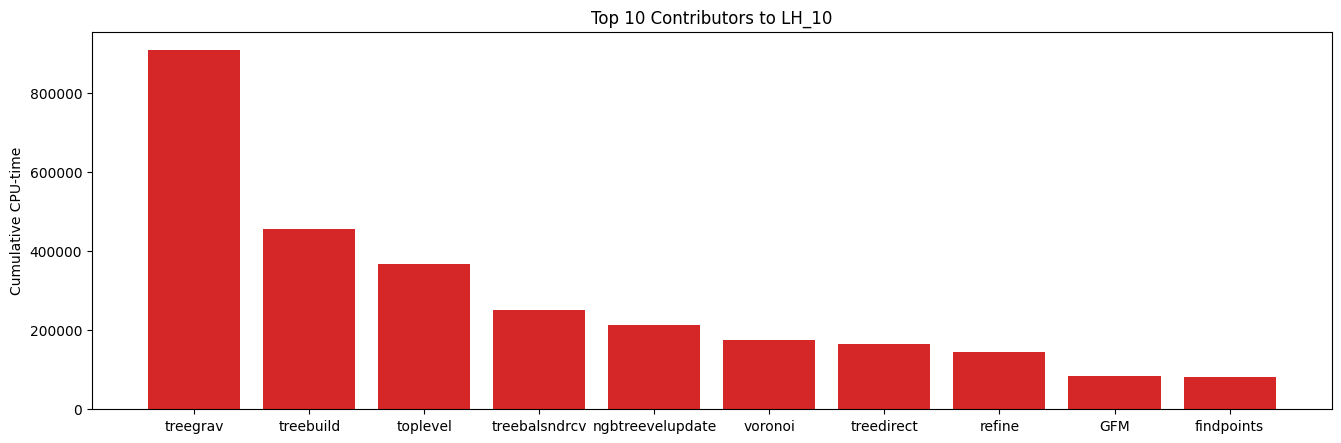

In [12]:
import re
import matplotlib.pyplot as plt

# Paste your log text here
log_text = """
total                   883.29  100.0%   0.00 1701824.29  100.0%
  treegrav               17.51    2.0%   0.04  909466.23        53.4%
    treebuild             3.15    0.4%   0.11  455415.99             26.8%
      insert              0.83    0.1%   0.86   80548.98                   4.7%
      toplevel            2.07    0.2%   2.16  366417.23                  21.5%
    treebalsndrcv         5.96    0.7%   7.94  251037.94             14.8%
    treeback              0.01    0.0%   0.02    1307.28              0.1%
    treedirect            0.15    0.0%   0.15  166336.31              9.8%
  ngbtreevelupdate        0.00    0.0%   0.00  212191.95        12.5%
  voronoi                16.92    1.9%   0.22  175922.71        10.3%
    findpoints           11.69    1.3%  12.02   81396.70              4.8%
    geometry              1.26    0.1%   1.29   33267.45              2.0%
  hydro                   0.94    0.1%   0.00   32238.36         1.9%
    fluxcomm              0.29    0.0%   0.39   24168.36              1.4%
  GFM                     1.45    0.2%   0.00   84630.27         5.0%
    enrich                1.10    0.1%   1.10   72605.11              4.3%
  subfind               162.32   18.4% 162.34   22024.02         1.3%
  refine                  0.00    0.0%   0.00  144672.84         8.5%
  restart               452.79   51.3% 464.43   33117.08         1.9%
  misc                   72.53    8.2%  76.49   18624.13         1.1%
"""

# Regex to extract task and cumulative time (4th column)
pattern = re.compile(r'^\s*([a-zA-Z0-9_]+)\s+[\d\.]+\s+[\d\.]+%\s+[\d\.]+\s+([\d\.]+)', re.MULTILINE)
matches = pattern.findall(log_text)

# Build a list of (task, cumulative_time)
tasks = [(name, float(cum)) for name, cum in matches if name != 'total']

# Sort by cumulative_time descending
tasks.sort(key=lambda x: x[1], reverse=True)

# Take top 10
top10 = tasks[:10]
labels, values = zip(*top10)

fig, ax = plt.subplots(dpi=100, figsize=(16,5))

# Plot
ax.bar(labels, values, color='C3')
ax.set_ylabel('Cumulative CPU-time')
ax.set_title('Top 10 Contributors to LH_10')